# Case Study - House Pricing

## Importing LIbraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#for mode operation
from statistics import mode

#scaling numerical data
from sklearn.preprocessing import MinMaxScaler

# mutual information library
# as the target column is sale price and it is continuous we use mutual_info_regression
from sklearn.feature_selection import mutual_info_regression

#encoding non numerical columns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# for train test split we have to import the method from scikit learn
from sklearn.model_selection import train_test_split



## Loading Dataset

In [2]:
file_path = '/content/drive/MyDrive/ICT - Ai Ml/Case Study/House_Pricing.csv'
house_df = pd.read_csv(file_path)
house_df.head(3)

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062


In [3]:
house_df.shape

(21613, 21)

## Dataset overview

In [4]:
house_df.shape

(21613, 21)

In [5]:
house_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [6]:
house_df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


## Duplicates Handling

In [7]:
house_df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
21608,False
21609,False
21610,False
21611,False


In [8]:
house_df.columns.duplicated().sum()

# no duplicate values to remove from the dataset

np.int64(0)

In [9]:
row_duplicates = house_df[house_df.duplicated()]
row_duplicates

# no row duplicated values

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)


## Missing Value checking

In [10]:
house_df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [11]:
# No of times visited contain more than 50% above null or missing values so we drop that column

house_df.drop(columns=['No of Times Visited'], inplace=True, axis=1)    # axis = 1 for columns

In [12]:
house_df.isnull().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
Condition of the House,0


In [13]:
# As missing value in the target column sale price we dont change any data so we have to remove the corresponding row.

print(house_df['Sale Price'].isna().sum())

house_df = house_df.dropna(subset=['Sale Price'], axis=0)

house_df.isna().sum()

4


,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
Condition of the House,0


## Dataset Visualization

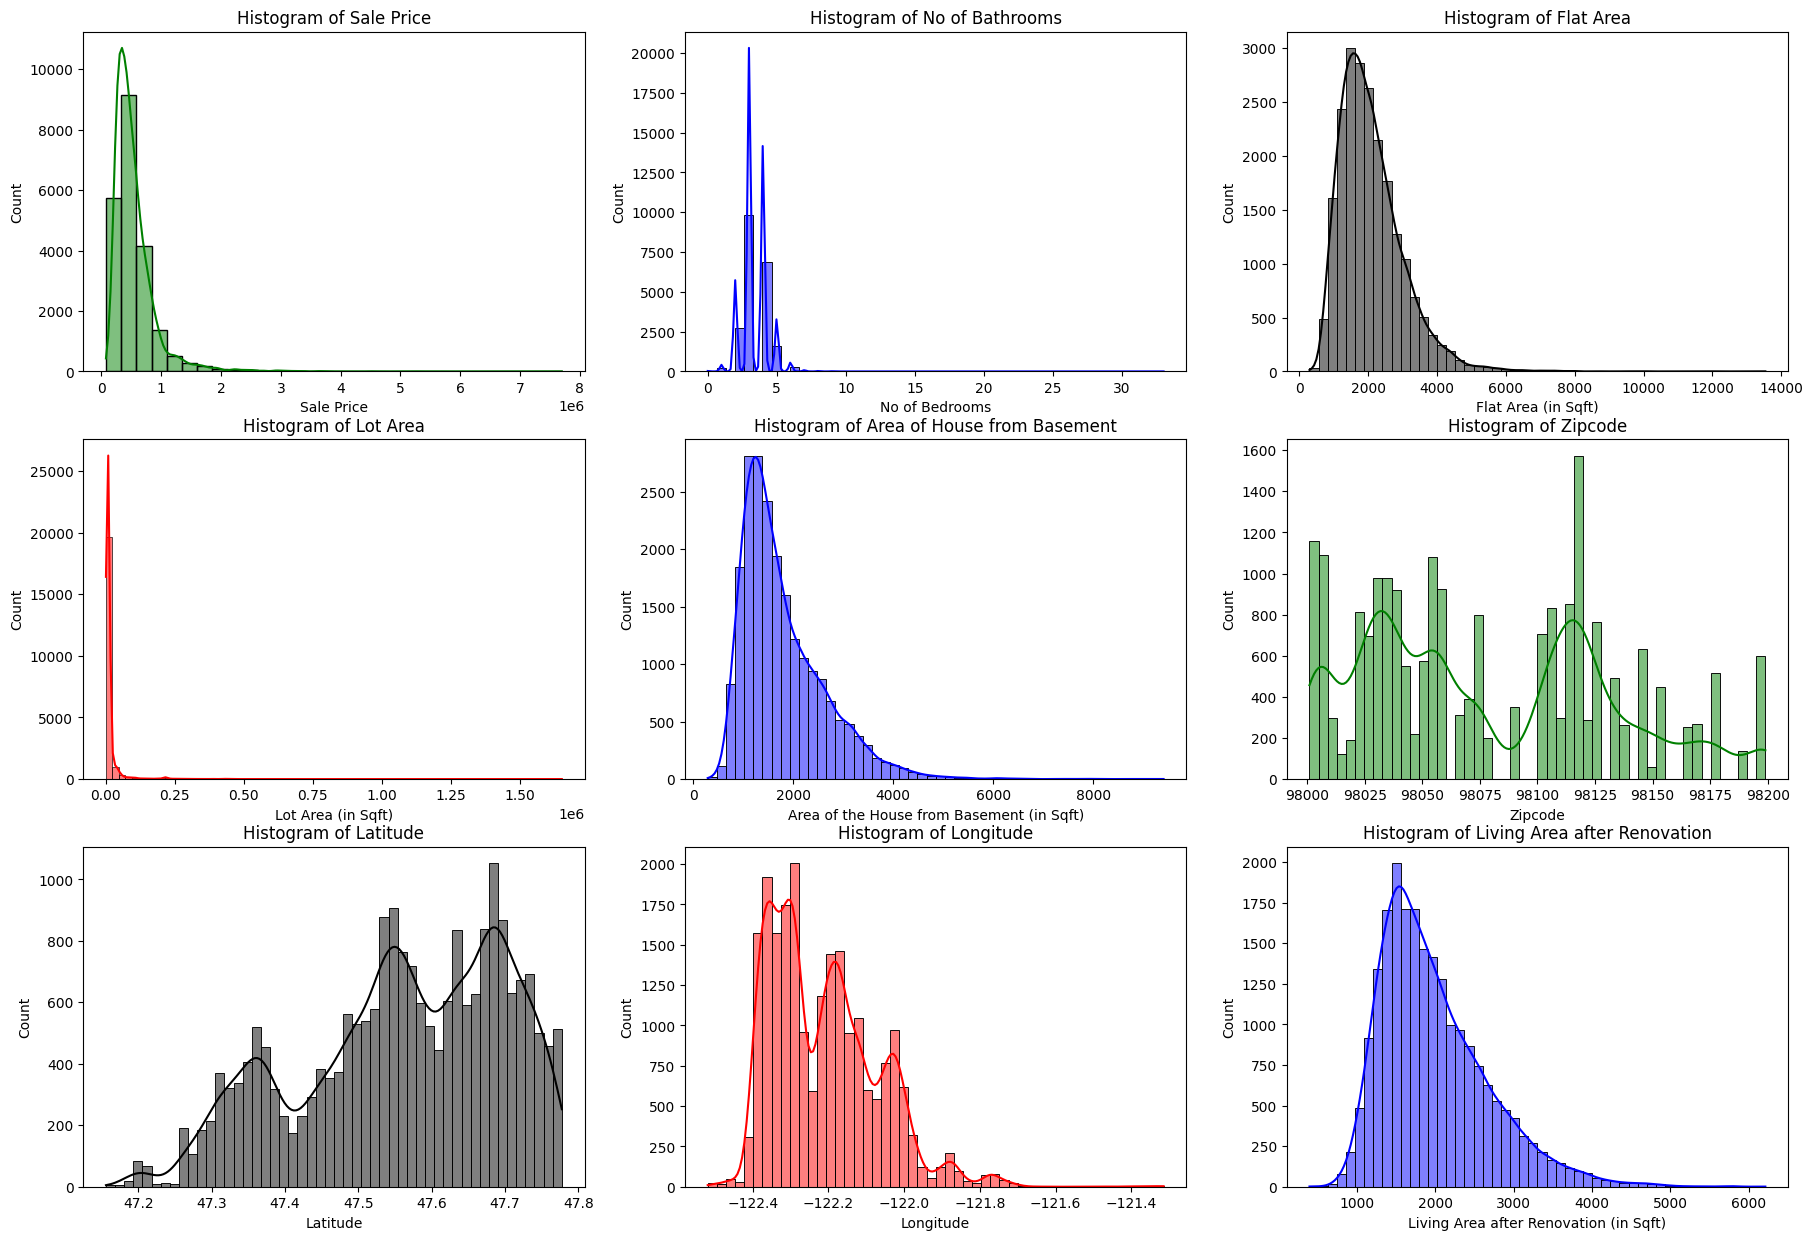

In [14]:
plt.figure(figsize=(22,15))

plt.subplot(3,3,1)
sns.histplot(house_df['Sale Price'], bins=30, kde=True, color='g')
plt.title('Histogram of Sale Price')

plt.subplot(3,3,2)
sns.histplot(house_df['No of Bedrooms'], kde=True, bins=50, color='b')
plt.title('Histogram of No of Bathrooms')

plt.subplot(3,3,3)
sns.histplot(house_df['Flat Area (in Sqft)'], kde=True, bins=50, color='k')
plt.title('Histogram of Flat Area')

plt.subplot(3,3,4)
sns.histplot(house_df['Lot Area (in Sqft)'], kde=True, bins=70, color='r')
plt.title('Histogram of Lot Area')

plt.subplot(3,3,5)
sns.histplot(house_df['Area of the House from Basement (in Sqft)'], kde=True, bins=50, color='b')
plt.title('Histogram of Area of House from Basement')

plt.subplot(3,3,6)
sns.histplot(house_df['Zipcode'], kde=True, bins=50, color='g')
plt.title('Histogram of Zipcode')

plt.subplot(3,3,7)
sns.histplot(house_df['Latitude'], kde=True, bins=50, color='k')
plt.title('Histogram of Latitude')

plt.subplot(3,3,8)
sns.histplot(house_df['Longitude'], kde=True, bins=50, color='r')
plt.title('Histogram of Longitude')

plt.subplot(3,3,9)
sns.histplot(house_df['Living Area after Renovation (in Sqft)'], kde=True, bins=50, color='b')
plt.title('Histogram of Living Area after Renovation')

plt.show()

## Missing Value Handling

In [15]:
house_df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
Condition of the House,0


In [16]:
house_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21609 entries, 0 to 21612
Data columns (total 20 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21609 non-null  int64  
 1   Date House was Sold                        21609 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21609 non-null  int64  
 4   No of Bathrooms                            21605 non-null  float64
 5   Flat Area (in Sqft)                        21600 non-null  float64
 6   Lot Area (in Sqft)                         21600 non-null  float64
 7   No of Floors                               21609 non-null  float64
 8   Waterfront View                            21609 non-null  object 
 9   Condition of the House                     21609 non-null  object 
 10  Overall Grade              

In [17]:

# as the no of bathroom columns are categorical column we use mode to fill missing value
house_df['No of Bathrooms'].fillna(mode(house_df['No of Bathrooms']), inplace=True)
print(house_df['No of Bathrooms'].isna().sum())

# as the columns is numerical and the data distribution is skewed
house_df['Flat Area (in Sqft)'].fillna(house_df['Flat Area (in Sqft)'].median(), inplace=True)
print(house_df['Flat Area (in Sqft)'].isna().sum())

house_df['Lot Area (in Sqft)'].fillna(house_df['Lot Area (in Sqft)'].median(), inplace=True)
print(house_df['Lot Area (in Sqft)'].isna().sum())

house_df['Area of the House from Basement (in Sqft)'].fillna(house_df['Area of the House from Basement (in Sqft)'].median(), inplace=True)
print(house_df['Area of the House from Basement (in Sqft)'].isna().sum())

house_df['Living Area after Renovation (in Sqft)'].fillna(house_df['Living Area after Renovation (in Sqft)'].median(), inplace=True)
print(house_df['Living Area after Renovation (in Sqft)'].isna().sum())

# as the latitude, longitude, zipcode are unique values and cant handle the missing values we should remove the rows contain missing value and also there is only 1 missing value its negligible
print(house_df.isna().sum())    # before removing these rows
print(house_df.shape)

house_df.dropna(subset=['Zipcode', 'Latitude', 'Longitude'], inplace=True, axis=0)

print('-----------------------------')
print(house_df.isna().sum())    # after removing these rows
print(house_df.shape)


0
0
0
0
0
ID                                           0
Date House was Sold                          0
Sale Price                                   0
No of Bedrooms                               0
No of Bathrooms                              0
Flat Area (in Sqft)                          0
Lot Area (in Sqft)                           0
No of Floors                                 0
Waterfront View                              0
Condition of the House                       0
Overall Grade                                0
Area of the House from Basement (in Sqft)    0
Basement Area (in Sqft)                      0
Age of House (in Years)                      0
Renovated Year                               0
Zipcode                                      1
Latitude                                     1
Longitude                                    1
Living Area after Renovation (in Sqft)       0
Lot Area after Renovation (in Sqft)          0
dtype: int64
(21609, 20)
-------------------------

/tmp/ipykernel_2095/1857827135.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  house_df['No of Bathrooms'].fillna(mode(house_df['No of Bathrooms']), inplace=True)
/tmp/ipykernel_2095/1857827135.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col]

In [18]:
house_df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


## Fixing Target and Feature Columns


In [19]:
# Target column is Sales price
y = house_df['Sale Price']

# expect the sales price all others are feature columns
X = house_df.drop(columns=['Sale Price'])

## Feature Engineering

In [20]:
num_cols = X.select_dtypes(include=['int64','float64']).columns    # Fetching numerical columns of feature
cat_cols = X.select_dtypes(include=['object']).columns             # Fetching categorical columns of feature

print(num_cols)
print(cat_cols)
# X.info()

Index(['ID', 'No of Bedrooms', 'No of Bathrooms', 'Flat Area (in Sqft)',
       'Lot Area (in Sqft)', 'No of Floors', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude',
       'Longitude', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')
Index(['Date House was Sold', 'Waterfront View', 'Condition of the House'], dtype='object')


In [21]:
X.nunique()


,0
ID,21429
Date House was Sold,13
No of Bedrooms,13
No of Bathrooms,30
Flat Area (in Sqft),1036
Lot Area (in Sqft),9778
No of Floors,6
Waterfront View,2
Condition of the House,5
Overall Grade,10


In [22]:
X_num_cols = X.drop(columns=['ID','No of Bedrooms', 'No of Bathrooms', 'No of Floors', 'Overall Grade', 'Zipcode','Waterfront View', 'Condition of the House', 'Date House was Sold'])
X_num_cols

,Flat Area (in Sqft),Lot Area (in Sqft),Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,1180.0,5650.0,1180.0,0,63,0,47.5112,-122.257,1340.0,5650
1,2570.0,7242.0,2170.0,400,67,1991,47.7210,-122.319,1690.0,7639
2,770.0,10000.0,770.0,0,85,0,47.7379,-122.233,2720.0,8062
3,1960.0,5000.0,1050.0,910,53,0,47.5208,-122.393,1360.0,5000
4,1680.0,8080.0,1680.0,0,31,0,47.6168,-122.045,1800.0,7503
...,...,...,...,...,...,...,...,...,...,...
21608,1530.0,1131.0,1530.0,0,9,0,47.6993,-122.346,1530.0,1509
21609,2310.0,5813.0,2310.0,0,4,0,47.5107,-122.362,1830.0,7200
21610,1020.0,1350.0,1020.0,0,9,0,47.5944,-122.299,1020.0,2007
21611,1600.0,2388.0,1600.0,0,14,0,47.5345,-122.069,1410.0,1287


## Split the column that contain the data in date format

we use df[['day', 'month', 'year']] = df['date'].str.split('_', expand=True)

In [23]:
X[['day', 'month', 'year']] = X['Date House was Sold'].str.split(' ', expand = True)
X.head(3)

,ID,Date House was Sold,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,...,Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),day,month,year
0,7129300520,14 October 2017,3,1.00,1180.0,5650.0,1.0,No,Fair,7,...,63,0,98178.0,47.5112,-122.257,1340.0,5650,14,October,2017
1,6414100192,14 December 2017,3,2.25,2570.0,7242.0,2.0,No,Fair,7,...,67,1991,98125.0,47.7210,-122.319,1690.0,7639,14,December,2017
2,5631500400,15 February 2016,2,1.00,770.0,10000.0,1.0,No,Fair,6,...,85,0,98028.0,47.7379,-122.233,2720.0,8062,15,February,2016


In [24]:
# Then drop the original column

X.drop(columns = ['Date House was Sold'], inplace = True)
X.head(3)

,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),...,Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),day,month,year
0,7129300520,3,1.00,1180.0,5650.0,1.0,No,Fair,7,1180.0,...,63,0,98178.0,47.5112,-122.257,1340.0,5650,14,October,2017
1,6414100192,3,2.25,2570.0,7242.0,2.0,No,Fair,7,2170.0,...,67,1991,98125.0,47.7210,-122.319,1690.0,7639,14,December,2017
2,5631500400,2,1.00,770.0,10000.0,1.0,No,Fair,6,770.0,...,85,0,98028.0,47.7379,-122.233,2720.0,8062,15,February,2016


## Scaling Numerical Columns

In [25]:
X_num_cols.head(10)

,Flat Area (in Sqft),Lot Area (in Sqft),Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,1180.0,5650.0,1180.0,0,63,0,47.5112,-122.257,1340.0,5650
1,2570.0,7242.0,2170.0,400,67,1991,47.7210,-122.319,1690.0,7639
2,770.0,10000.0,770.0,0,85,0,47.7379,-122.233,2720.0,8062
3,1960.0,5000.0,1050.0,910,53,0,47.5208,-122.393,1360.0,5000
4,1680.0,8080.0,1680.0,0,31,0,47.6168,-122.045,1800.0,7503
5,5420.0,101930.0,3890.0,1530,17,0,47.6561,-122.005,4760.0,101930
6,1715.0,6819.0,1715.0,0,23,0,47.3097,-122.327,2238.0,6819
7,1060.0,9711.0,1060.0,0,55,0,47.4095,-122.315,1650.0,9711
8,1780.0,7470.0,1050.0,730,58,0,47.5123,-122.337,1780.0,8113
9,1890.0,6560.0,1890.0,0,15,0,47.3684,-122.031,2390.0,7570


In [26]:
# Scaling the numerical columns of the feature column as it all are skewed we can use normalization ( MinMax Scaling )
min_max_scaler = MinMaxScaler()
skewed_cols = ['year', 'day', 'Flat Area (in Sqft)',	'Lot Area (in Sqft)',	'Area of the House from Basement (in Sqft)',	'Basement Area (in Sqft)',	'Age of House (in Years)',	'Renovated Year',	'Latitude',	'Longitude',	'Living Area after Renovation (in Sqft)',	'Lot Area after Renovation (in Sqft)']

X[skewed_cols] = min_max_scaler.fit_transform(X[skewed_cols])

In [27]:
X.head(10)

,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),...,Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),day,month,year
0,7129300520,3,1.00,0.067170,0.003108,1.0,No,Fair,7,0.097588,...,0.521739,0.000000,98178.0,0.571498,0.217608,0.161934,0.005742,0.0,October,1.0
1,6414100192,3,2.25,0.172075,0.004072,2.0,No,Fair,7,0.206140,...,0.556522,0.988089,98125.0,0.908959,0.166113,0.222165,0.008027,0.0,December,1.0
2,5631500400,2,1.00,0.036226,0.005743,1.0,No,Fair,6,0.052632,...,0.713043,0.000000,98028.0,0.936143,0.237542,0.399415,0.008513,1.0,February,0.0
3,2487200875,4,3.00,0.126038,0.002714,1.0,No,Excellent,7,0.083333,...,0.434783,0.000000,98136.0,0.586939,0.104651,0.165376,0.004996,0.0,December,1.0
4,1954400510,3,2.00,0.104906,0.004579,1.0,No,Fair,8,0.152412,...,0.243478,0.000000,98074.0,0.741354,0.393688,0.241094,0.007871,1.0,February,0.0
5,7237550310,4,4.50,0.387170,0.061429,1.0,No,Fair,10,0.394737,...,0.121739,0.000000,98053.0,0.804568,0.426910,0.750473,0.116339,0.0,May,1.0
6,1321400060,3,2.25,0.107547,0.003816,2.0,No,Fair,7,0.156250,...,0.173913,0.000000,98003.0,0.247386,0.159468,0.316469,0.007085,0.0,June,1.0
7,2008000270,3,1.50,0.058113,0.005567,1.0,No,Fair,7,0.084430,...,0.452174,0.000000,98198.0,0.407914,0.169435,0.215281,0.010407,1.0,January,0.0
8,2414600126,3,1.00,0.112453,0.004210,1.0,No,Fair,7,0.083333,...,0.478261,0.000000,98146.0,0.573267,0.151163,0.237653,0.008572,1.0,April,0.0
9,3793500160,3,2.50,0.120755,0.003659,2.0,No,Fair,7,0.175439,...,0.104348,0.000000,98038.0,0.341805,0.405316,0.342626,0.007948,1.0,March,0.0


## Encoding the categorical columns

In [28]:
print(X.select_dtypes(include='object').columns)

Index(['Waterfront View', 'Condition of the House', 'month'], dtype='object')


In [29]:
X['month'].unique()

array(['October', 'December', 'February', 'May', 'June', 'January',
       'April', 'March', 'July', 'August', 'November', 'September'],
      dtype=object)

In [30]:
X['Waterfront View'].unique()

array(['No', 'Yes'], dtype=object)

In [31]:
X['Condition of the House'].unique()

array(['Fair', 'Excellent', 'Good', 'Bad', 'Okay'], dtype=object)

### Label Encoding

In [32]:
# Before encoding
X.head(3)

,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),...,Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),day,month,year
0,7129300520,3,1.00,0.067170,0.003108,1.0,No,Fair,7,0.097588,...,0.521739,0.000000,98178.0,0.571498,0.217608,0.161934,0.005742,0.0,October,1.0
1,6414100192,3,2.25,0.172075,0.004072,2.0,No,Fair,7,0.206140,...,0.556522,0.988089,98125.0,0.908959,0.166113,0.222165,0.008027,0.0,December,1.0
2,5631500400,2,1.00,0.036226,0.005743,1.0,No,Fair,6,0.052632,...,0.713043,0.000000,98028.0,0.936143,0.237542,0.399415,0.008513,1.0,February,0.0


In [33]:
# we use label encoding on the columns contain binary categories or on target column

label_encoder_obj = LabelEncoder()

X['Waterfront View'] = label_encoder_obj.fit_transform(X['Waterfront View'])

In [34]:
# after encoding
X.head(3)

,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),...,Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),day,month,year
0,7129300520,3,1.00,0.067170,0.003108,1.0,0,Fair,7,0.097588,...,0.521739,0.000000,98178.0,0.571498,0.217608,0.161934,0.005742,0.0,October,1.0
1,6414100192,3,2.25,0.172075,0.004072,2.0,0,Fair,7,0.206140,...,0.556522,0.988089,98125.0,0.908959,0.166113,0.222165,0.008027,0.0,December,1.0
2,5631500400,2,1.00,0.036226,0.005743,1.0,0,Fair,6,0.052632,...,0.713043,0.000000,98028.0,0.936143,0.237542,0.399415,0.008513,1.0,February,0.0


### OneHotEncoding

In [35]:
# Before encoding
X.head(3)

,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),...,Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),day,month,year
0,7129300520,3,1.00,0.067170,0.003108,1.0,0,Fair,7,0.097588,...,0.521739,0.000000,98178.0,0.571498,0.217608,0.161934,0.005742,0.0,October,1.0
1,6414100192,3,2.25,0.172075,0.004072,2.0,0,Fair,7,0.206140,...,0.556522,0.988089,98125.0,0.908959,0.166113,0.222165,0.008027,0.0,December,1.0
2,5631500400,2,1.00,0.036226,0.005743,1.0,0,Fair,6,0.052632,...,0.713043,0.000000,98028.0,0.936143,0.237542,0.399415,0.008513,1.0,February,0.0


In [36]:
OHE_obj = OneHotEncoder(sparse_output=False)
ohe_cols = ['Condition of the House', 'month']

encoded_data = OHE_obj.fit_transform(X[ohe_cols])
encoded_cols = OHE_obj.get_feature_names_out(ohe_cols)

encoded_X = pd.DataFrame(encoded_data, columns = encoded_cols, index = X.index)
encoded_X.head(3)


,Condition of the House_Bad,Condition of the House_Excellent,Condition of the House_Fair,Condition of the House_Good,Condition of the House_Okay,month_April,month_August,month_December,month_February,month_January,month_July,month_June,month_March,month_May,month_November,month_October,month_September
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
X = pd.concat([X.drop(columns = ohe_cols), encoded_X], axis = 1)
X.head(10)

,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),...,month_December,month_February,month_January,month_July,month_June,month_March,month_May,month_November,month_October,month_September
0,7129300520,3,1.00,0.067170,0.003108,1.0,0,7,0.097588,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,6414100192,3,2.25,0.172075,0.004072,2.0,0,7,0.206140,0.082988,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5631500400,2,1.00,0.036226,0.005743,1.0,0,6,0.052632,0.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2487200875,4,3.00,0.126038,0.002714,1.0,0,7,0.083333,0.188797,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1954400510,3,2.00,0.104906,0.004579,1.0,0,8,0.152412,0.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,7237550310,4,4.50,0.387170,0.061429,1.0,0,10,0.394737,0.317427,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6,1321400060,3,2.25,0.107547,0.003816,2.0,0,7,0.156250,0.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7,2008000270,3,1.50,0.058113,0.005567,1.0,0,7,0.084430,0.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,2414600126,3,1.00,0.112453,0.004210,1.0,0,7,0.083333,0.151452,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,3793500160,3,2.50,0.120755,0.003659,2.0,0,7,0.175439,0.000000,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [38]:
## After encoding
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21606 entries, 0 to 21612
Data columns (total 36 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21606 non-null  int64  
 1   No of Bedrooms                             21606 non-null  int64  
 2   No of Bathrooms                            21606 non-null  float64
 3   Flat Area (in Sqft)                        21606 non-null  float64
 4   Lot Area (in Sqft)                         21606 non-null  float64
 5   No of Floors                               21606 non-null  float64
 6   Waterfront View                            21606 non-null  int64  
 7   Overall Grade                              21606 non-null  int64  
 8   Area of the House from Basement (in Sqft)  21606 non-null  float64
 9   Basement Area (in Sqft)                    21606 non-null  float64
 10  Age of House (in Years)    

## Mutual Information of Dataset

In [39]:
# mutual information of each column in 'X_encode' with respect to 'y'

mi = mutual_info_regression(X, y)

# converting into a dataframe
mi_X = pd.DataFrame({'Features' : X.columns, 'mutual Information':mi})
mi_X

,Features,mutual Information
0,ID,0.109953
1,No of Bedrooms,0.084364
2,No of Bathrooms,0.203337
3,Flat Area (in Sqft),0.351417
4,Lot Area (in Sqft),0.061340
5,No of Floors,0.070233
6,Waterfront View,0.011524
7,Overall Grade,0.340308
8,Area of the House from Basement (in Sqft),0.261356
9,Basement Area (in Sqft),0.072176


In [40]:
selected_features = mi_X[mi_X['mutual Information'] > 0.01]
selected_features

,Features,mutual Information
0,ID,0.109953
1,No of Bedrooms,0.084364
2,No of Bathrooms,0.203337
3,Flat Area (in Sqft),0.351417
4,Lot Area (in Sqft),0.061340
5,No of Floors,0.070233
6,Waterfront View,0.011524
7,Overall Grade,0.340308
8,Area of the House from Basement (in Sqft),0.261356
9,Basement Area (in Sqft),0.072176


In [41]:
# we only needed if the mutual information >0.01 so selected those meet the criteria and updating the dataframe X so it contain that much importand data only.

X = X[selected_features['Features'].tolist()]
X.head()

,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,3,1.00,0.067170,0.003108,1.0,0,7,0.097588,0.000000,0.521739,98178.0,0.571498,0.217608,0.161934,0.005742
1,6414100192,3,2.25,0.172075,0.004072,2.0,0,7,0.206140,0.082988,0.556522,98125.0,0.908959,0.166113,0.222165,0.008027
2,5631500400,2,1.00,0.036226,0.005743,1.0,0,6,0.052632,0.000000,0.713043,98028.0,0.936143,0.237542,0.399415,0.008513
3,2487200875,4,3.00,0.126038,0.002714,1.0,0,7,0.083333,0.188797,0.434783,98136.0,0.586939,0.104651,0.165376,0.004996
4,1954400510,3,2.00,0.104906,0.004579,1.0,0,8,0.152412,0.000000,0.243478,98074.0,0.741354,0.393688,0.241094,0.007871


## Outlier Handling

### Boxplot Before Handling Outlier

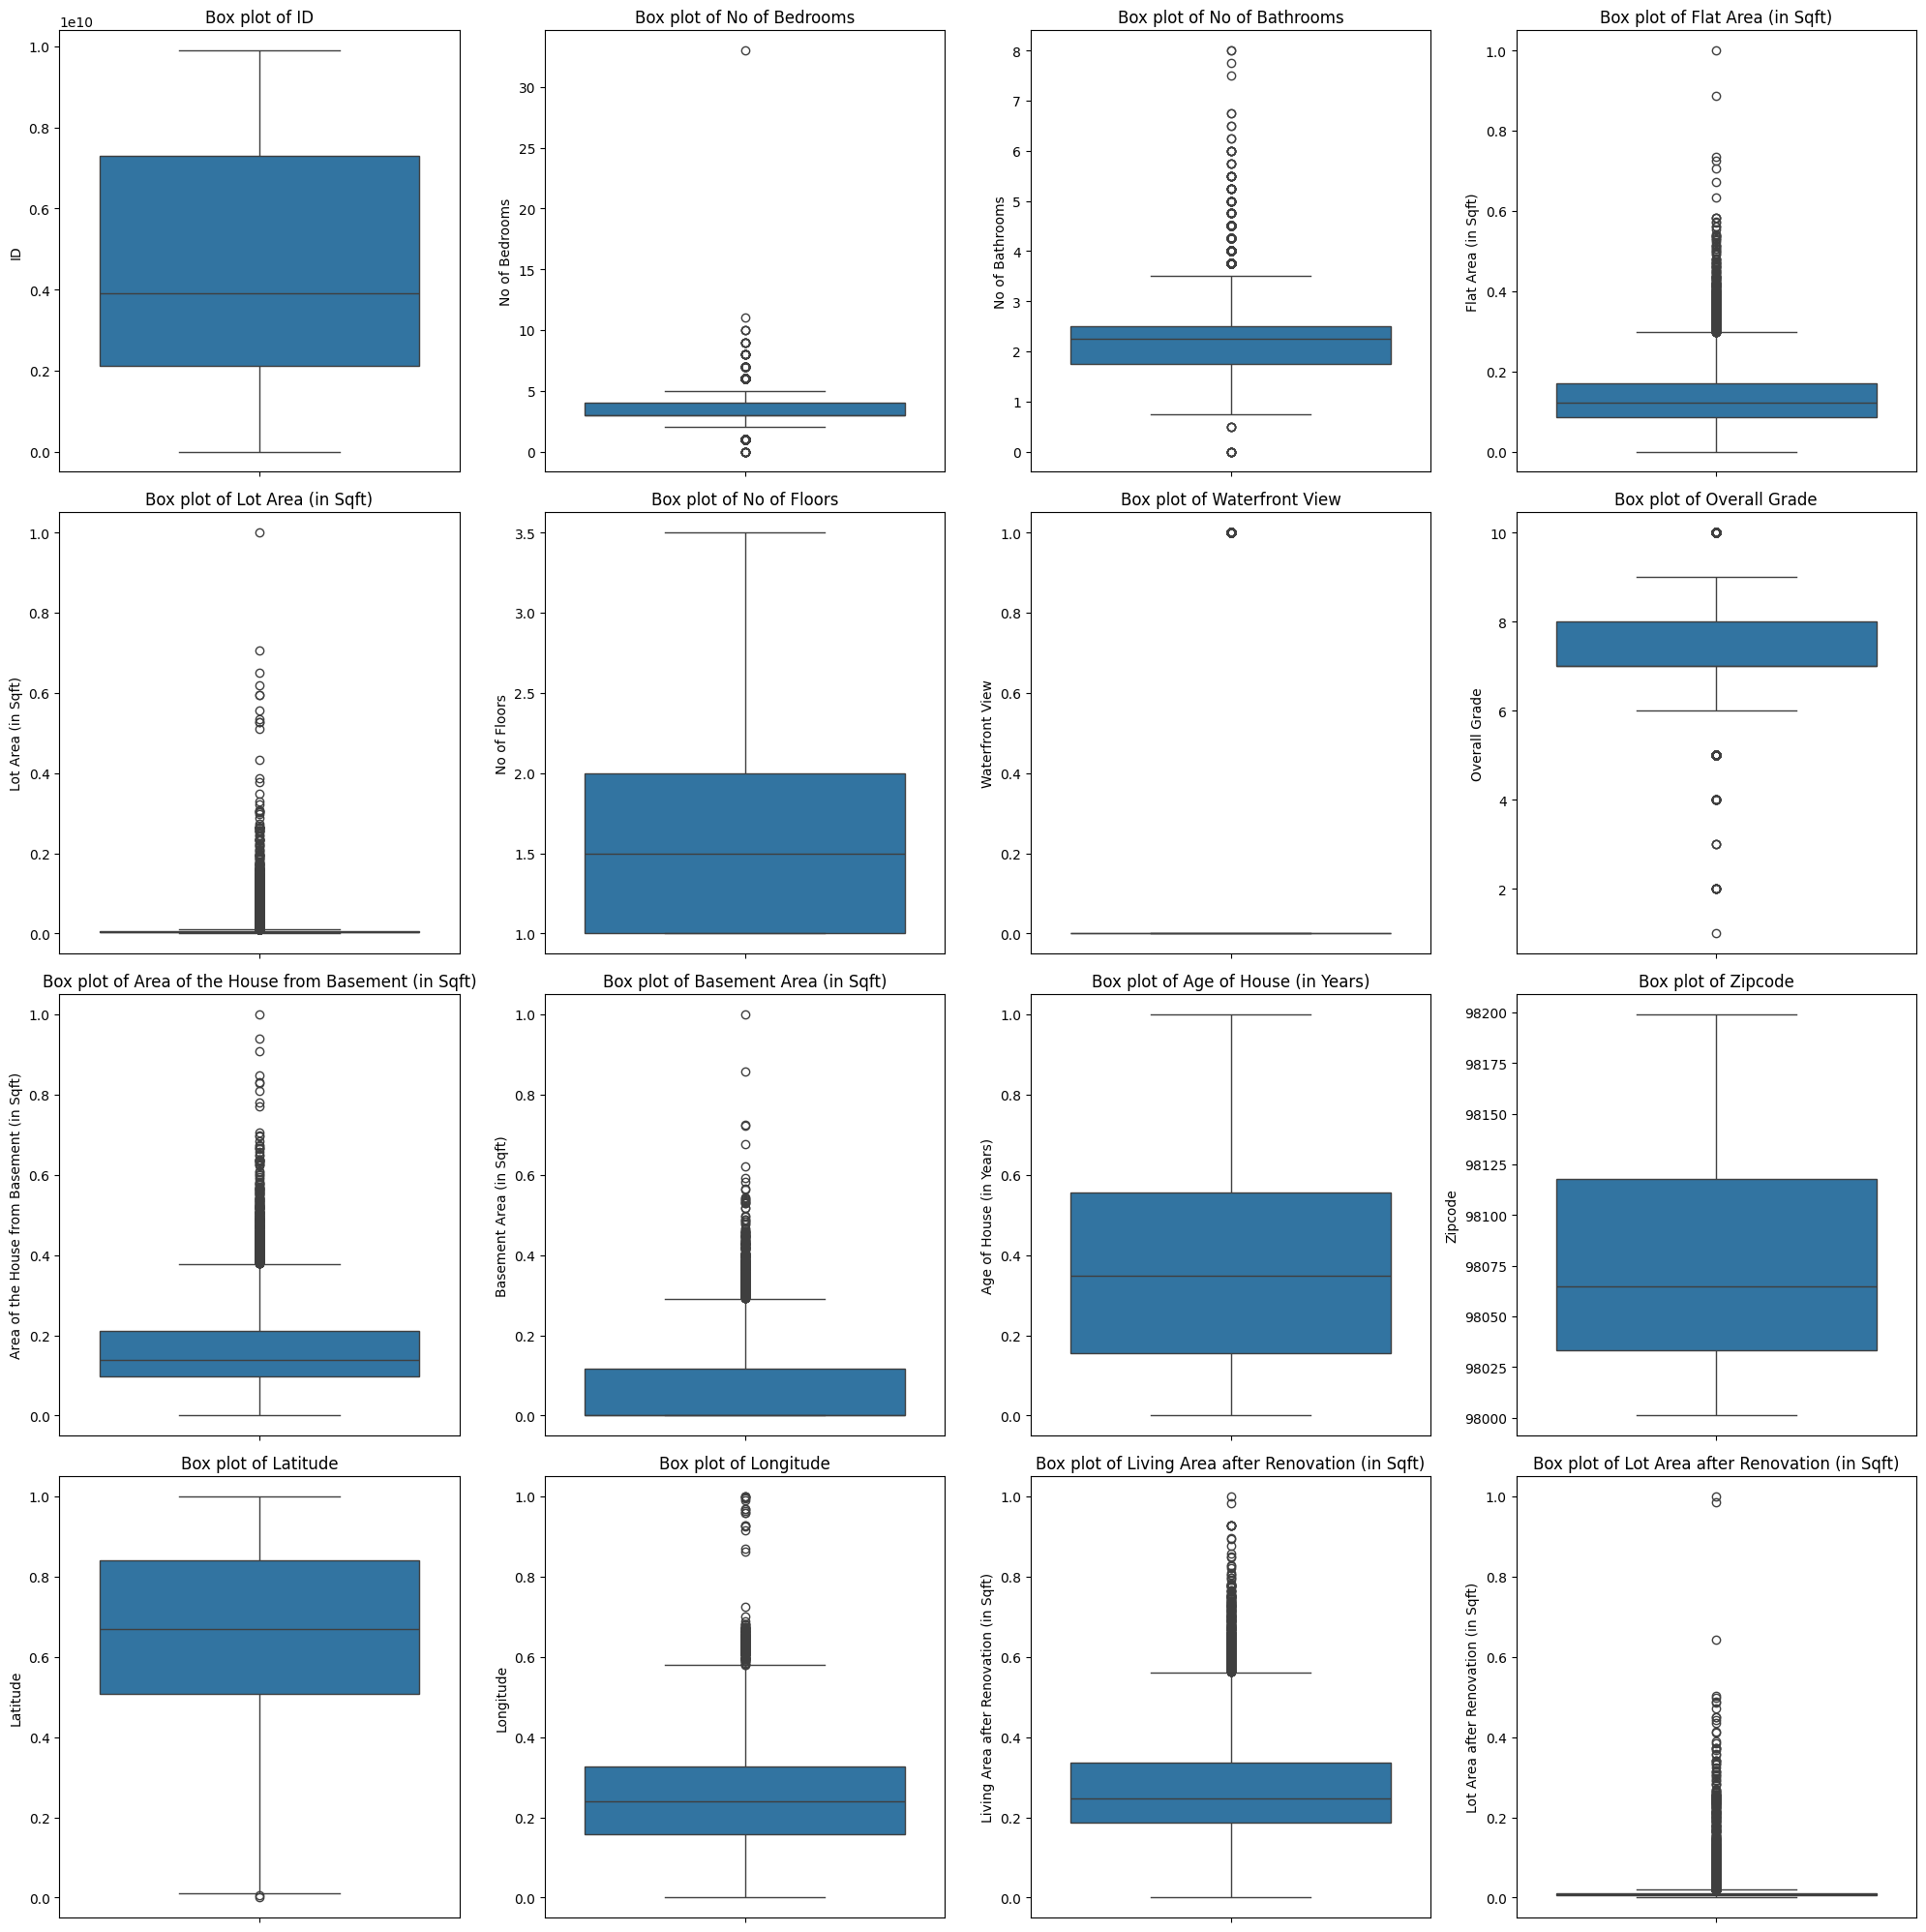

In [42]:
plt.figure(figsize=(20, 25))

for i, column in enumerate(X.columns):
    plt.subplot(5, 4, i + 1)
    sns.boxplot(y=X[column])
    plt.title(f'Box plot of {column}')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

### Outlier Handling

In [43]:
def clip_outliers_iqr(column):
    Q1 = X[column].quantile(0.25)
    Q3 = X[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    X[column] = np.clip(X[column], lower_bound, upper_bound)
    return X

# Apply outlier clipping to all columns in X
for column in X.columns:
    X = clip_outliers_iqr(column)

print(f"Shape of X after outlier clipping: {X.shape}")
X.head()

Shape of X after outlier clipping: (21606, 16)


,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,3.0,1.00,0.067170,0.003108,1.0,0,7.0,0.097588,0.000000,0.521739,98178.0,0.571498,0.217608,0.161934,0.005742
1,6414100192,3.0,2.25,0.172075,0.004072,2.0,0,7.0,0.206140,0.082988,0.556522,98125.0,0.908959,0.166113,0.222165,0.008027
2,5631500400,2.0,1.00,0.036226,0.005743,1.0,0,6.0,0.052632,0.000000,0.713043,98028.0,0.936143,0.237542,0.399415,0.008513
3,2487200875,4.0,3.00,0.126038,0.002714,1.0,0,7.0,0.083333,0.188797,0.434783,98136.0,0.586939,0.104651,0.165376,0.004996
4,1954400510,3.0,2.00,0.104906,0.004579,1.0,0,8.0,0.152412,0.000000,0.243478,98074.0,0.741354,0.393688,0.241094,0.007871


### Boxplot After Handling Outlier

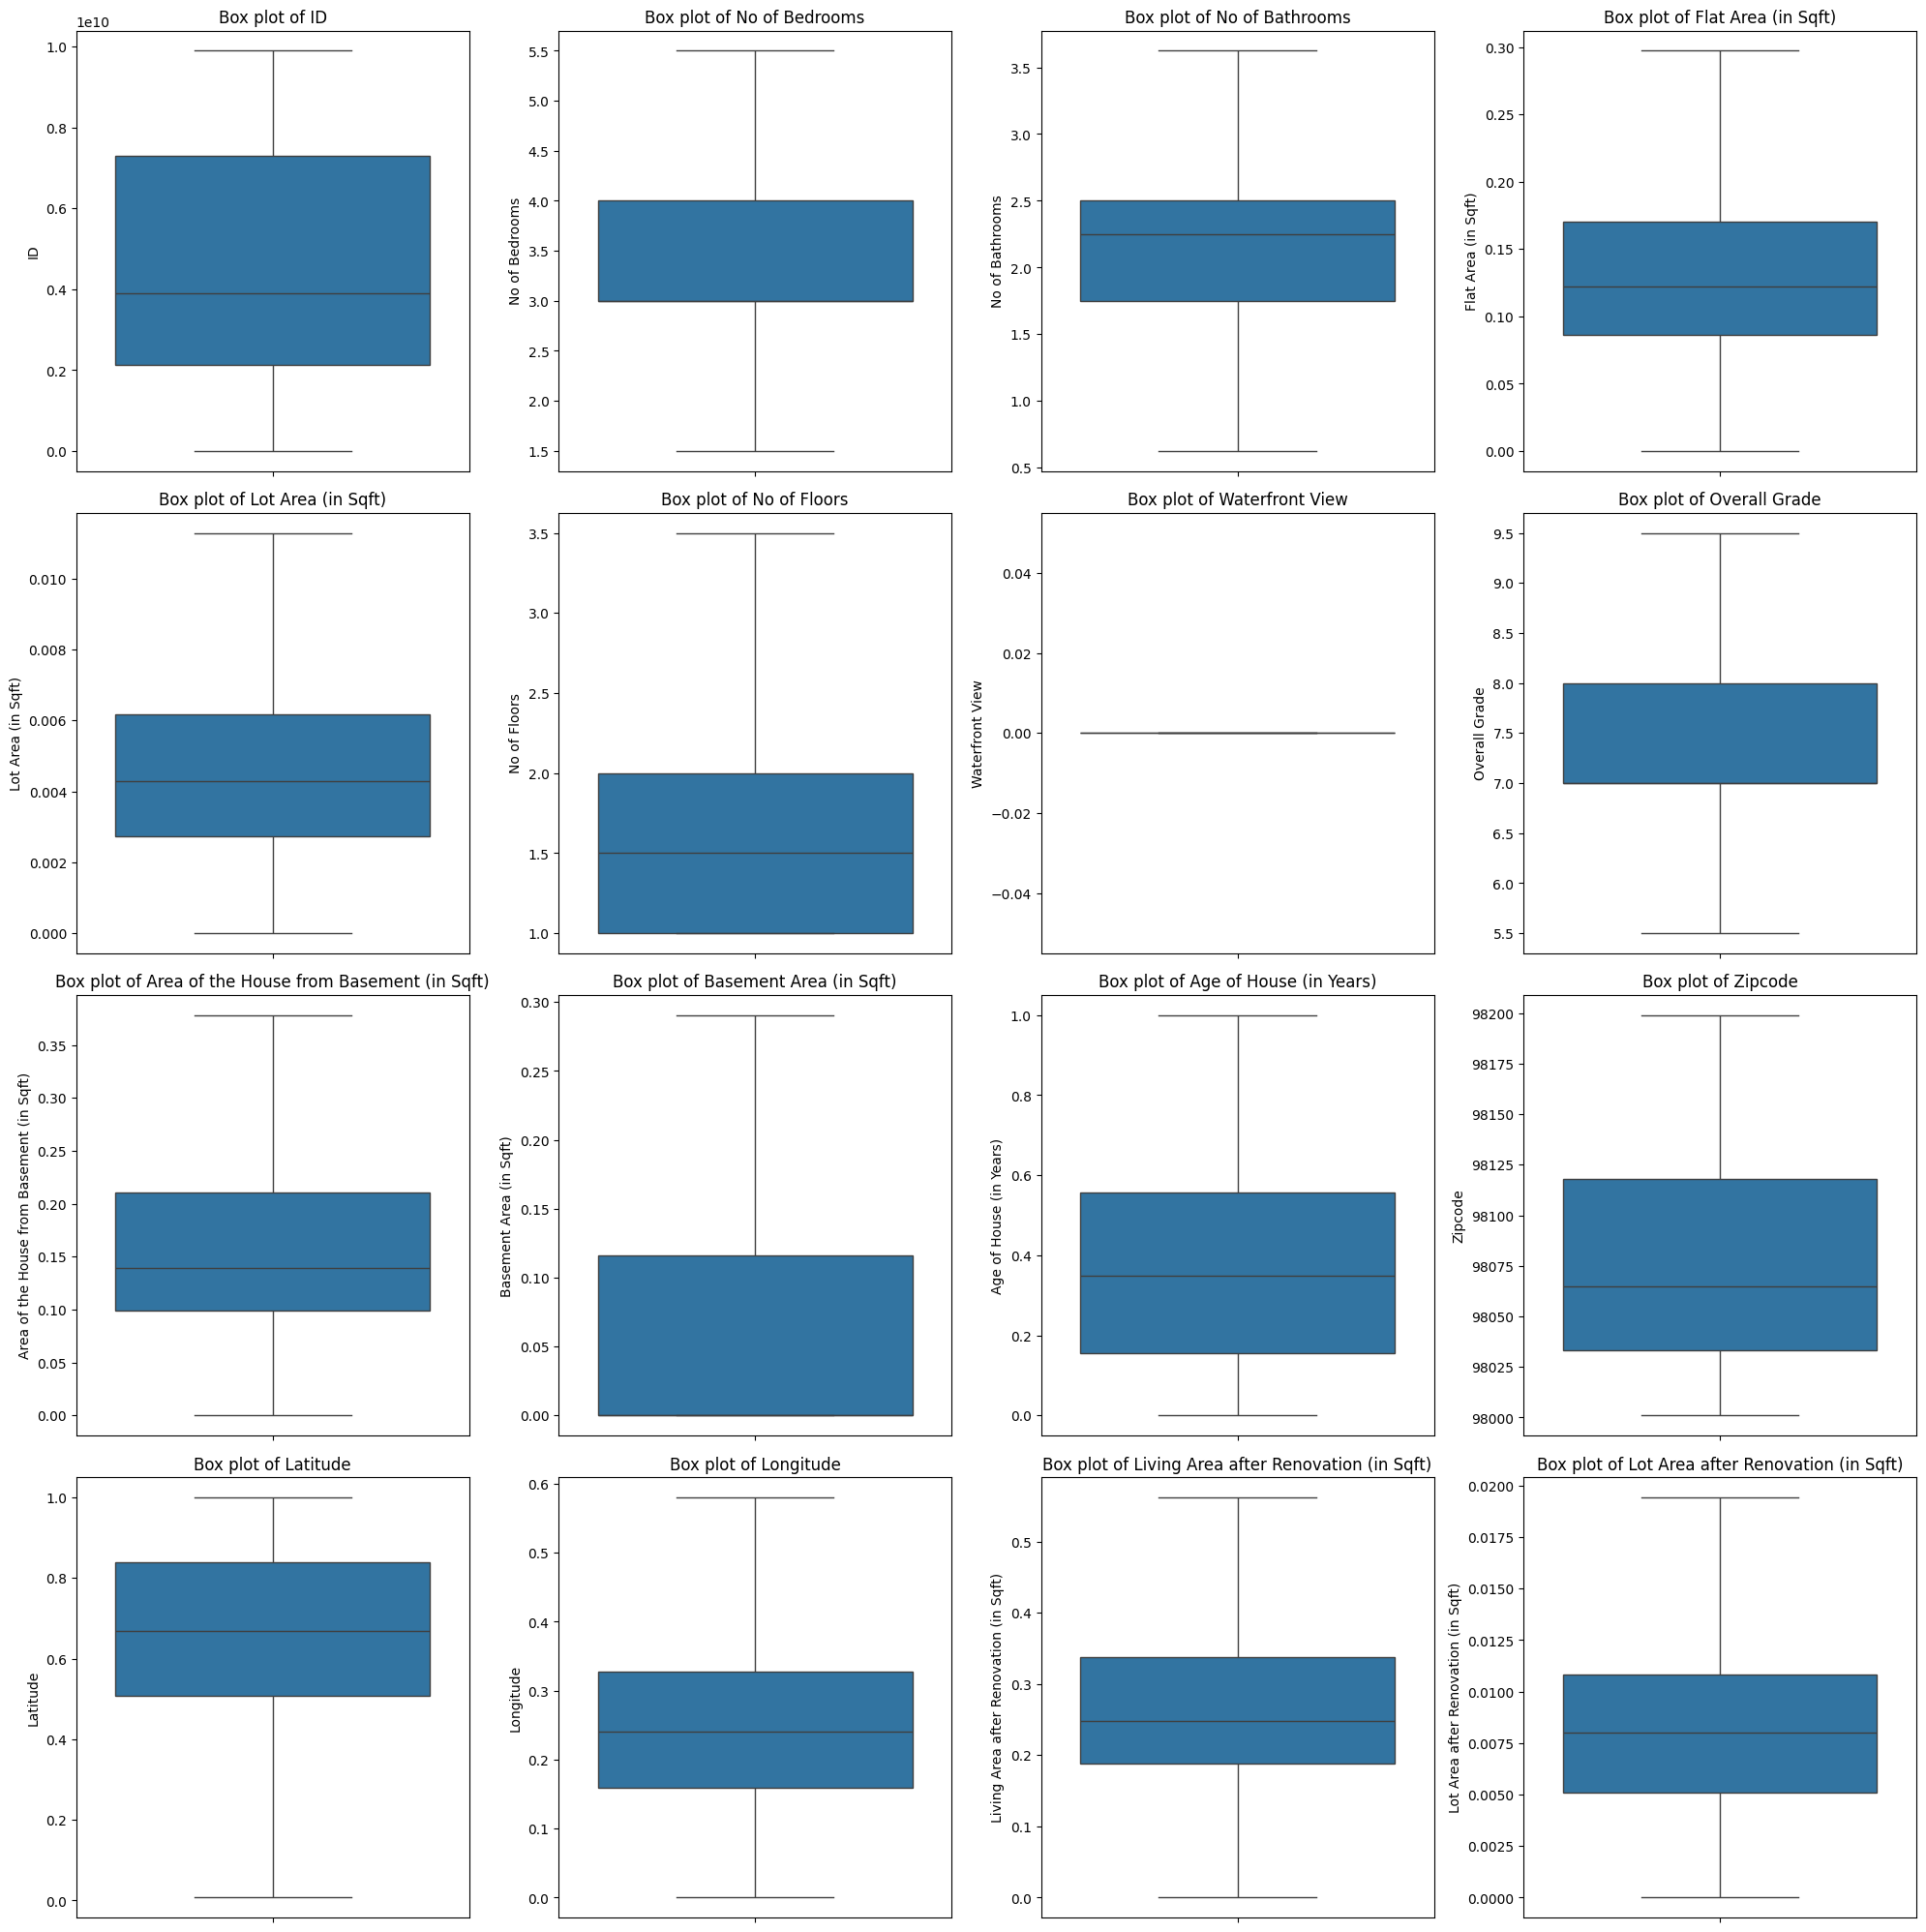

In [44]:
plt.figure(figsize=(20, 25))

for i, column in enumerate(X.columns):
    plt.subplot(5, 4, i + 1)
    sns.boxplot(y=X[column])
    plt.title(f'Box plot of {column}')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

## Train Test Split

In [45]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)    # test_size indicate 0.2 means 20% of data, random_state used for random shuffiing logic

In [46]:
X_train

,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
19150,1324300018,2.0,2.25,0.064151,0.000492,3.0,0,8.0,0.093202,0.000000,0.139130,98103.0,0.801673,0.135382,0.127517,0.000708
6253,514500235,3.0,1.50,0.056604,0.005938,1.0,0,7.0,0.082237,0.000000,0.495652,98005.0,0.695351,0.302326,0.203235,0.007523
13666,8860300220,5.0,2.50,0.151698,0.003925,1.0,0,8.0,0.109649,0.209544,0.347826,98052.0,0.855075,0.329734,0.289279,0.007615
7246,1446403850,2.0,1.00,0.037736,0.004018,1.0,0,6.0,0.054825,0.000000,0.617391,98168.0,0.532411,0.161960,0.070728,0.007440
17292,3630020380,3.0,2.50,0.089057,0.000763,2.0,0,8.0,0.095395,0.064315,0.086957,98029.0,0.629403,0.432724,0.184306,0.001063
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11969,114100354,3.0,1.00,0.060377,0.005922,1.0,0,6.0,0.087719,0.000000,0.565217,98028.0,0.994692,0.215116,0.260024,0.011079
21582,3052700432,3.0,2.25,0.091321,0.000466,2.0,0,8.0,0.101974,0.058091,0.078261,98117.0,0.840598,0.119601,0.182585,0.000832
5395,8658300480,4.0,1.50,0.093585,0.005137,1.0,0,6.0,0.135965,0.000000,0.339130,98014.0,0.793470,0.507475,0.192910,0.009016
865,2310000240,3.0,2.25,0.085283,0.004864,2.0,0,7.0,0.123904,0.000000,0.226087,98038.0,0.324433,0.398671,0.199793,0.007834


In [47]:
X_test

,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
9402,425069020,4.0,2.500,0.297358,0.011289,2.5,0,9.5,0.378289,0.000000,0.200000,98053.0,0.843815,0.391196,0.399415,0.019428
15751,6744700427,5.5,3.625,0.257358,0.004317,2.0,0,8.0,0.373904,0.000000,0.582609,98155.0,0.938395,0.191030,0.363277,0.007843
9999,8594400060,3.0,2.250,0.104906,0.011289,2.0,0,7.0,0.152412,0.000000,0.243478,98092.0,0.235805,0.375415,0.244536,0.019428
10976,1186000125,4.0,2.750,0.212075,0.001971,2.0,0,8.0,0.187500,0.228216,0.834783,98122.0,0.739746,0.189369,0.297883,0.003591
3048,7852020300,3.0,2.500,0.144151,0.002438,2.0,0,8.0,0.209430,0.000000,0.130435,98065.0,0.604793,0.541528,0.344347,0.005491
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12939,5379800040,2.0,1.750,0.135849,0.006540,1.0,0,7.0,0.087719,0.207469,0.730435,98188.0,0.488178,0.199336,0.265187,0.012252
2527,4123400320,4.0,2.250,0.128302,0.004357,1.0,0,8.0,0.100877,0.161826,0.365217,98027.0,0.664147,0.358804,0.227327,0.007745
21153,2419700080,4.0,2.500,0.197736,0.002324,3.0,0,8.0,0.287281,0.000000,0.043478,98034.0,0.827730,0.309801,0.420065,0.004055
16296,5113400168,3.0,1.750,0.139623,0.003203,1.0,0,7.0,0.085526,0.221992,0.591304,98119.0,0.784301,0.121262,0.263466,0.005924


In [48]:
y_train

,Sale Price
19150,476000.0
6253,411100.0
13666,612000.0
7246,212000.0
17292,379770.0
...,...
11969,249000.0
21582,490000.0
5395,299800.0
865,275000.0


In [49]:
y_test

,Sale Price
9402,1090000.0
15751,540000.0
9999,285000.0
10976,742500.0
3048,525000.0
...,...
12939,275000.0
2527,627000.0
21153,915000.0
16296,620000.0


## Model Selection

## Evaluation Metrices

 The error is the deference b/w the target value and the predicted output. <br>
 Then we can take several measures to neglect the -ve value ; <br>
 1. Mean Absolute Error (MAE)
 2. Mean Squared Error (MSE)

 Taking the average of the mean help to evaluate the performance of the model.

### Mean Absolute Error (MAE)

### Mean Squared Error (MSE)